In [ ]:
# ═══════════════════════════════════════════════
# GOOGLE COLAB: run this cell first, then Runtime → Restart runtime
# On your own machine: this cell is harmless — it does nothing.
# ═══════════════════════════════════════════════
import sys, os, subprocess
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if "stereocomplex" not in sys.modules:
        print("Installing StereoComplex on Colab…")
        !git clone https://github.com/jeffwitz/StereoComplex.git /tmp/SC
        !pip install -e /tmp/SC 2>&1 | tail -2
        sys.path.insert(0, "/tmp/SC/src")
        print("✅ Done. Now Runtime → Restart runtime, then run all cells.")
    else:
        print("Already installed.")
else:
    print("Local environment — no action needed.")


# 06 - CMO rayfield measurement and optical model selection

This notebook isolates the model-selection workflow that was introduced at the
end of notebook 04 and applies it to a Common Main Objective (CMO) stereo
prototype.

The workflow is deliberately two-stage:

1. generate a CMO stereo rayfield with the physics implemented in
   `stereocomplex.physics`;
2. identify a generic Zernike rayfield `(O(u,v), d(u,v))` from the generated
   rays;
3. fit several physical hypotheses to the measured Zernike rayfield;
4. select the model that best explains the measured rayfield in ray space.

The important point is the separation of roles:

> The 2D/ray observations measure the rayfield; the rayfield is then used to
> identify and compare optical models.

In this notebook the CMO oracle and the CMO physical fitting candidate are the
same shared-rig model from `stereocomplex.physics`. The polynomial model is
tested as a more generic surrogate, not used to generate the fields.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares

from stereocomplex.physics import (
    CMOIntrinsics,
    CMOPhysicalStereoModel,
    NonCentralPolynomialChannelModel,
    CMOPlaneTargetSpec,
    CentralBrownConradyModel,
    CentralPinholeModel,
    PhysicalModelSpec,
    PinholeParallelPlateModel,
    Vignetting,
    fit_cmo_physical_stereo_model_to_rayfields,
    generate_cmo_plane_dataset,
    intersect_rays_with_plane,
    rayfield_two_plane_residuals,
    sample_cmo_target_texture,
    select_physical_model_from_rayfield,
)
from stereocomplex.physics.cmo import CMOChannelSpec, CMOStereoSpec, pose_from_euler_xyz
from stereocomplex.rayfields import (
    ZernikeOriginFieldConfig,
    ZernikeRayField,
    ZernikeRayFieldCoefficients,
)


def find_repo_root(start: Path) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "pyproject.toml").exists() and (path / "src" / "stereocomplex").exists():
            return path
    raise RuntimeError("Could not find the StereoComplex repository root")


ROOT = find_repo_root(Path.cwd())
ASSET_DIR = ROOT / "docs" / "assets" / "cmo_model_selection"
ASSET_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repository root: {ROOT}")
print(f"Assets: {ASSET_DIR}")


def show_or_close(fig) -> None:
    if "ipykernel" in sys.modules:
        plt.show()
    else:
        plt.close(fig)

Repository root: /home/jeff/StereoComplex
Assets: /home/jeff/StereoComplex/docs/assets/cmo_model_selection


## 1. Build a physical CMO stereo oracle

The oracle is the compact shared-rig CMO model:

- one common main objective focal length;
- one working plane where both chief rays cross the optical axis;
- one sub-pupil baseline shared by the two channels;
- one tube-lens scale and pixel pitch;
- per-channel Brown-Conrady distortion.

This matters for model selection: the polynomial channel model is more
generic, so it could generate rayfields that the physical CMO cannot represent.
Here we do the stricter experiment and generate the fields with the physical
CMO, then ask whether the physical CMO beats the generic surrogate as a compact
explanation of the measured `O,d` fields.

In [2]:
IMAGE_SIZE = (320, 240)
F_OBJ_MM = 80.0
WORKING_DISTANCE_MM = 120.0
B_MM = 8.0
F_TUBE_MM = 50.0
PIXEL_PITCH_MM = 0.05
CX = (IMAGE_SIZE[0] - 1) / 2.0
CY = (IMAGE_SIZE[1] - 1) / 2.0

physical_cmo = CMOPhysicalStereoModel(
    f_obj_mm=F_OBJ_MM,
    working_distance_mm=WORKING_DISTANCE_MM,
    b_mm=B_MM,
    f_tube_mm=F_TUBE_MM,
    cx_principal_px=CX,
    cy_principal_px=CY,
    pixel_pitch_mm=PIXEL_PITCH_MM,
    distortion_left=(-0.04, 0.01, 2.0e-4, -1.0e-4, 0.0),
    distortion_right=(-0.035, 0.008, -2.0e-4, 1.0e-4, 0.0),
    image_size=IMAGE_SIZE,
)

intr = CMOIntrinsics(
    width=IMAGE_SIZE[0],
    height=IMAGE_SIZE[1],
    fx=F_TUBE_MM / PIXEL_PITCH_MM,
    fy=F_TUBE_MM / PIXEL_PITCH_MM,
    cx=CX,
    cy=CY,
)
K = intr.as_K()
left_true = physical_cmo.channel("left")
right_true = physical_cmo.channel("right")

print("Physical CMO oracle")
print(f"  f_obj / working distance : {F_OBJ_MM:.1f} / {WORKING_DISTANCE_MM:.1f} mm")
print(f"  sub-pupil baseline       : {B_MM:.1f} mm")
print(f"  angular pixel scale      : {PIXEL_PITCH_MM / F_TUBE_MM:.4e} rad/px")

Physical CMO oracle
  f_obj / working distance : 80.0 / 120.0 mm
  sub-pupil baseline       : 8.0 mm
  angular pixel scale      : 1.0000e-03 rad/px


## 2. Render a small physical-CMO calibration scene

The rendered image is not used for the fits below. It is included to show that
the same physics object can generate images and rayfields. The renderer uses:

$$
\text{pixel}\rightarrow\text{physical CMO ray}\rightarrow
\text{target plane}\rightarrow\text{texture sample}.
$$

Wrote docs/assets/cmo_model_selection/generated_cmo_dataset


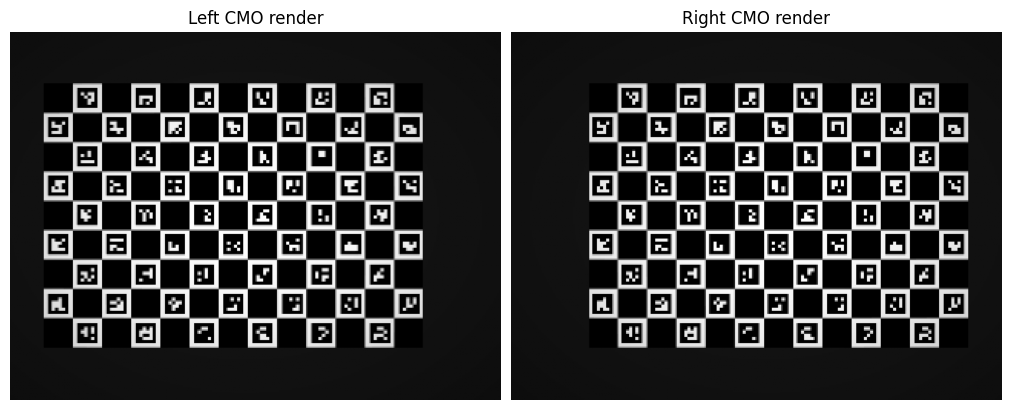

In [3]:
target = CMOPlaneTargetSpec(
    squares_x=13,
    squares_y=9,
    square_size_mm=4.0,
    pixels_per_square=36,
    pattern="charuco",
)
pose = pose_from_euler_xyz(0.0, 0.0, 0.0, (0.0, 0.0, 180.0))
texture = target.make_texture_u8()

render_intr_left = CMOChannelSpec(
    name="left",
    intrinsics=intr,
    origin_world_mm=(0.0, 0.0, 0.0),
    vignetting=Vignetting(strength=0.16, floor=0.55, x_shift=-0.04),
)
render_intr_right = CMOChannelSpec(
    name="right",
    intrinsics=intr,
    origin_world_mm=(0.0, 0.0, 0.0),
    vignetting=Vignetting(strength=0.16, floor=0.55, x_shift=+0.04),
)


def render_physical_cmo_channel(channel: str) -> np.ndarray:
    u, v = intr.pixel_grid()
    origins, directions = physical_cmo.ray(u, v, channel)  # same physics used by fitting
    X_world, valid = intersect_rays_with_plane(origins, directions, pose)
    X_local = pose.world_to_local(X_world)
    xy = X_local[..., :2]
    inside = (
        valid
        & (xy[..., 0] >= -0.5 * target.width_mm)
        & (xy[..., 0] <= +0.5 * target.width_mm)
        & (xy[..., 1] >= -0.5 * target.height_mm)
        & (xy[..., 1] <= +0.5 * target.height_mm)
    )
    sampled = sample_cmo_target_texture(target, texture, xy, inside, interpolation="linear")
    img = np.full_like(sampled, 20, dtype=np.uint8)
    img[inside] = sampled[inside]
    channel_spec = render_intr_left if channel == "left" else render_intr_right
    return np.clip(img.astype(float) * channel_spec.vignetting.gain(intr), 0.0, 255.0).astype(np.uint8)


left_img = render_physical_cmo_channel("left")
right_img = render_physical_cmo_channel("right")

# Also write a tiny ChArUco dataset with the existing polynomial renderer API so
# downstream image-front-end examples still have files to inspect. It is not used
# for the rayfield fits below.
render_only_cmo = CMOStereoSpec(
    left=render_intr_left,
    right=render_intr_right,
)

dataset_dir = ASSET_DIR / "generated_cmo_dataset"
generate_cmo_plane_dataset(
    out_dir=dataset_dir,
    cmo=render_only_cmo,
    target=target,
    poses=[pose],
    noise_std_gray=0.0,
    blur_sigma_px=0.6,
)
print(f"Wrote {dataset_dir.relative_to(ROOT)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].imshow(left_img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Left CMO render")
axes[1].imshow(right_img, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Right CMO render")
for ax in axes:
    ax.axis("off")
fig.savefig(ASSET_DIR / "cmo_rendered_pair.png", dpi=160)
show_or_close(fig)

## 3. Measure generic Zernike rayfields O(u,v), d(u,v)

In a real workflow, the rayfield would come from images, detections, and BA. In
this controlled notebook we isolate the model-selection question by fitting a
generic Zernike rayfield directly to the generated CMO rays.

The fitted object is deliberately generic:

$$
\widehat{\mathcal R}_Z(u,v)=
\left(\widehat O(u,v), \widehat d(u,v)\right).
$$

It does not know that the oracle was a CMO.

In [4]:
def grid_pixels(image_size: tuple[int, int], grid_shape: tuple[int, int]) -> np.ndarray:
    width, height = image_size
    nx, ny = grid_shape
    u = np.linspace(0.0, width - 1.0, nx)
    v = np.linspace(0.0, height - 1.0, ny)
    uu, vv = np.meshgrid(u, v)
    return np.column_stack([uu.reshape(-1), vv.reshape(-1)])


def residual_norms(residuals: np.ndarray) -> np.ndarray:
    return np.linalg.norm(np.asarray(residuals).reshape(-1, 6), axis=1)


def fit_zernike_rayfield_to_target(
    target_field,
    K: np.ndarray,
    image_size: tuple[int, int],
    max_order: int = 3,
    grid_shape: tuple[int, int] = (11, 9),
    z_planes: tuple[float, float] = (80.0, 260.0),
) -> tuple[ZernikeRayField, np.ndarray, object]:
    config = ZernikeOriginFieldConfig(image_size=image_size, max_order=max_order)
    template = ZernikeRayField(K, config)
    n_terms = len(template.modes)
    pixels = grid_pixels(image_size, grid_shape)
    x0 = np.zeros(2 * n_terms * 3, dtype=np.float64)

    def field_from_vector(x: np.ndarray) -> ZernikeRayField:
        arr = np.asarray(x, dtype=np.float64)
        origin = arr[: n_terms * 3].reshape(n_terms, 3)
        direction = arr[n_terms * 3 :].reshape(n_terms, 3)
        return ZernikeRayField(K, config, ZernikeRayFieldCoefficients(origin, direction))

    def objective(x: np.ndarray) -> np.ndarray:
        field = field_from_vector(x)
        data = rayfield_two_plane_residuals(target_field, field, pixels, z_planes=z_planes)
        # Weakly damp the direction field; otherwise a flexible model can trade
        # equivalent line changes between origin and direction coefficients.
        direction = x[n_terms * 3 :]
        return np.r_[data, 1.0e-3 * direction]

    result = least_squares(
        objective,
        x0=x0,
        loss="huber",
        f_scale=1.0,
        max_nfev=400,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10,
    )
    return field_from_vector(result.x), pixels, result


left_zernike, support_left, left_fit = fit_zernike_rayfield_to_target(left_true, K, IMAGE_SIZE)
right_zernike, support_right, right_fit = fit_zernike_rayfield_to_target(right_true, K, IMAGE_SIZE)

for name, true_field, z_field, fit in [
    ("left", left_true, left_zernike, left_fit),
    ("right", right_true, right_zernike, right_fit),
]:
    residuals = rayfield_two_plane_residuals(true_field, z_field, grid_pixels(IMAGE_SIZE, (17, 13)))
    norms = residual_norms(residuals)
    print(f"{name} Zernike O+d fit")
    print(f"  success       : {fit.success}")
    print(f"  n coeffs      : {z_field.origin_coeffs.size + z_field.direction_coeffs.size}")
    print(f"  ray RMS       : {np.sqrt(np.mean(norms**2)):.4f} mm")
    print(f"  ray median    : {np.median(norms):.4f} mm")
    print(f"  ray P95       : {np.percentile(norms, 95):.4f} mm")

left Zernike O+d fit
  success       : True
  n coeffs      : 60
  ray RMS       : 0.0063 mm
  ray median    : 0.0054 mm
  ray P95       : 0.0098 mm
right Zernike O+d fit
  success       : True
  n coeffs      : 60
  ray RMS       : 0.0064 mm
  ray median    : 0.0055 mm
  ray P95       : 0.0099 mm


## 4. Define physical candidates

The measured Zernike rayfield is the target. The physical candidates are
hypotheses:

- central pinhole;
- central Brown-Conrady;
- pinhole plus inclined parallel plate;
- effective CMO polynomial channel.

The CMO candidate has more parameters, so BIC penalizes it. It should still win
if it explains the measured rayfield substantially better.

In [5]:
def cmo_candidate_specs(image_size: tuple[int, int]) -> list[PhysicalModelSpec]:
    terms = NonCentralPolynomialChannelModel.default_terms()
    cmo_initial = np.zeros(7 + 2 * len(terms), dtype=np.float64)
    cmo_bounds = (
        np.r_[[-12.0, -12.0, -1.0, -1.0, -0.1, -0.1, -1.0], -0.05 * np.ones(2 * len(terms))],
        np.r_[[+12.0, +12.0, +1.0, +1.0, +0.1, +0.1, +1.0], +0.05 * np.ones(2 * len(terms))],
    )
    return [
        PhysicalModelSpec("central_pinhole", CentralPinholeModel, np.zeros(0)),
        PhysicalModelSpec(
            "central_brown_conrady",
            CentralBrownConradyModel,
            np.zeros(5),
            bounds=(
                np.array([-1.0, -1.0, -0.1, -0.1, -1.0], dtype=np.float64),
                np.array([+1.0, +1.0, +0.1, +0.1, +1.0], dtype=np.float64),
            ),
        ),
        PhysicalModelSpec(
            "pinhole_parallel_plate",
            PinholeParallelPlateModel,
            np.array([0.0, 0.0, 8.0], dtype=np.float64),
            bounds=(
                np.array([-30.0, -30.0, 0.0], dtype=np.float64),
                np.array([+30.0, +30.0, 50.0], dtype=np.float64),
            ),
            model_kwargs={"eta": 1.5, "d1_mm": 80.0},
        ),
        PhysicalModelSpec(
            "polynomial_surrogate_channel",
            NonCentralPolynomialChannelModel,
            cmo_initial,
            bounds=cmo_bounds,
            model_kwargs={"cmo_image_size": image_size, "aberration_terms": terms},
        ),
    ]


left_report = select_physical_model_from_rayfield(
    target_field=left_zernike,
    candidate_specs=cmo_candidate_specs(IMAGE_SIZE),
    K=K,
    image_size=IMAGE_SIZE,
    grid_shape=(13, 11),
    support_pixels=support_left,
    full_grid_weight=0.35,
    max_nfev=500,
)
right_report = select_physical_model_from_rayfield(
    target_field=right_zernike,
    candidate_specs=cmo_candidate_specs(IMAGE_SIZE),
    K=K,
    image_size=IMAGE_SIZE,
    grid_shape=(13, 11),
    support_pixels=support_right,
    full_grid_weight=0.35,
    max_nfev=500,
)


def print_report(label: str, report) -> None:
    print(label)
    print(f"  best by BIC: {report.best_by_bic}")
    print(f"  best by RMS: {report.best_by_rms}")
    for row in report.rows():
        marker = "*" if row["selected_bic"] else " "
        print(
            f"{marker} {row['model']:<26s} "
            f"p={row['parameters']:>2d} "
            f"rms={row['rms_mm']:>8.4f} "
            f"support={row['support_rms_mm']:>8.4f} "
            f"full={row['full_grid_rms_mm']:>8.4f} "
            f"BIC={row['bic']:>10.1f}"
        )


print_report("Left measured Zernike rayfield", left_report)
print()
print_report("Right measured Zernike rayfield", right_report)

Left measured Zernike rayfield
  best by BIC: polynomial_surrogate_channel
  best by RMS: polynomial_surrogate_channel
  central_pinhole            p= 0 rms= 71.2721 support= 71.2721 full= 70.5532 BIC=    8722.6
  central_brown_conrady      p= 5 rms= 65.7305 support= 65.7305 full= 65.2367 BIC=    8516.2
  pinhole_parallel_plate     p= 3 rms= 71.2439 support= 71.2439 full= 70.5243 BIC=    8738.0
* polynomial_surrogate_channel     p=17 rms= 59.7594 support= 59.7594 full= 59.3952 BIC=    8306.1

Right measured Zernike rayfield
  best by BIC: polynomial_surrogate_channel
  best by RMS: polynomial_surrogate_channel
  central_pinhole            p= 0 rms= 71.2557 support= 71.2557 full= 70.5377 BIC=    8722.0
  central_brown_conrady      p= 5 rms= 65.7143 support= 65.7143 full= 65.2214 BIC=    8515.4
  pinhole_parallel_plate     p= 3 rms= 71.2273 support= 71.2273 full= 70.5085 BIC=    8737.3
* polynomial_surrogate_channel     p=17 rms= 59.7435 support= 59.7435 full= 59.3800 BIC=    8305.3


## 5. Shared physical CMO vs polynomial surrogate

The previous table fits every candidate per channel. That is useful for
diagnostics, but it is not the fairest comparison for a real CMO: the physical
model shares one stereo rig across both channels. We therefore run a shared
physical CMO fit on the left and right measured `O,d` rayfields together, and
compare it to the two independent polynomial-channel fits.

The polynomial surrogate is still useful. It can represent optical systems that
are not constrained by a common main objective: Greenough-like microscopes with
independent objectives, decentered relays, tilted sensor stacks, unknown
protective windows, or generic non-central stereo rigs. Its cost is lower
interpretability and more degrees of freedom.

In [6]:
def selected_candidate(report, name: str):
    by_name = {candidate.model_name: candidate for candidate in report.candidates}
    return by_name[name]


poly_left = selected_candidate(left_report, "polynomial_surrogate_channel")
poly_right = selected_candidate(right_report, "polynomial_surrogate_channel")
poly_combined_rms = float(np.sqrt(0.5 * (poly_left.rms_mm**2 + poly_right.rms_mm**2)))
poly_combined_bic = float(poly_left.bic + poly_right.bic)
poly_combined_aic = float(poly_left.aic + poly_right.aic)
poly_parameter_count = int(poly_left.n_parameters + poly_right.n_parameters)

physical_initial = physical_cmo.parameter_vector().copy()
physical_initial[:4] *= np.array([1.03, 0.98, 1.05, 0.97])
physical_initial[4:6] += np.array([0.25, -0.15])
physical_initial[7:17] *= 0.8

physical_fit = fit_cmo_physical_stereo_model_to_rayfields(
    left_field=left_zernike,
    right_field=right_zernike,
    image_size=IMAGE_SIZE,
    initial_parameters=physical_initial,
    pixel_pitch_mm=PIXEL_PITCH_MM,
    z_planes=(80.0, 260.0),
    grid_shape=(13, 11),
    support_pixels_left=support_left,
    support_pixels_right=support_right,
    full_grid_weight=0.35,
    max_nfev=800,
)

truth_params = physical_cmo.parameter_vector()
fit_params = physical_fit.parameter_vector
angular_scale_truth = PIXEL_PITCH_MM / truth_params[3]
angular_scale_fit = PIXEL_PITCH_MM / fit_params[3]

comparison_rows = [
    {
        "model": "polynomial_surrogate",
        "parameters": poly_parameter_count,
        "rms_mm": poly_combined_rms,
        "left_rms_mm": float(poly_left.rms_mm),
        "right_rms_mm": float(poly_right.rms_mm),
        "bic": poly_combined_bic,
        "aic": poly_combined_aic,
    },
    {
        "model": "physical_cmo_shared",
        "parameters": physical_fit.n_parameters,
        "rms_mm": float(physical_fit.rms_mm),
        "left_rms_mm": float(physical_fit.left_rms_mm),
        "right_rms_mm": float(physical_fit.right_rms_mm),
        "bic": float(physical_fit.bic),
        "aic": float(physical_fit.aic),
    },
]

print("Shared physical CMO vs polynomial surrogate")
for row in comparison_rows:
    print(
        f"  {row['model']:<24s} "
        f"p={row['parameters']:>2d} "
        f"rms={row['rms_mm']:.5f} mm "
        f"left={row['left_rms_mm']:.5f} "
        f"right={row['right_rms_mm']:.5f} "
        f"BIC={row['bic']:.1f}"
    )
print("Physical CMO identifiable parameters")
print(f"  f_obj truth/fit        : {truth_params[0]:.4f} / {fit_params[0]:.4f} mm")
print(f"  working truth/fit      : {truth_params[1]:.4f} / {fit_params[1]:.4f} mm")
print(f"  baseline truth/fit     : {truth_params[2]:.4f} / {fit_params[2]:.4f} mm")
print(f"  angular scale truth/fit: {angular_scale_truth:.6e} / {angular_scale_fit:.6e}")

Shared physical CMO vs polynomial surrogate
  polynomial_surrogate     p=34 rms=59.75144 mm left=59.75941 right=59.74346 BIC=16611.4
  physical_cmo_shared      p=17 rms=0.00093 mm left=0.00092 right=0.00094 BIC=-47785.0
Physical CMO identifiable parameters
  f_obj truth/fit        : 80.0000 / 80.0000 mm
  working truth/fit      : 120.0000 / 120.0000 mm
  baseline truth/fit     : 8.0000 / 8.0000 mm
  angular scale truth/fit: 1.000000e-03 / 9.999531e-04


The physical CMO was used to generate the rayfields. On this controlled case it
should therefore achieve a similar or better ray-space fit with fewer
parameters. The polynomial surrogate remains valuable when this structural CMO
hypothesis is false: it can absorb smooth non-central effects without assuming
a shared objective, shared sub-pupil baseline, or chief-ray crossover.

## 6. Visualize model selection

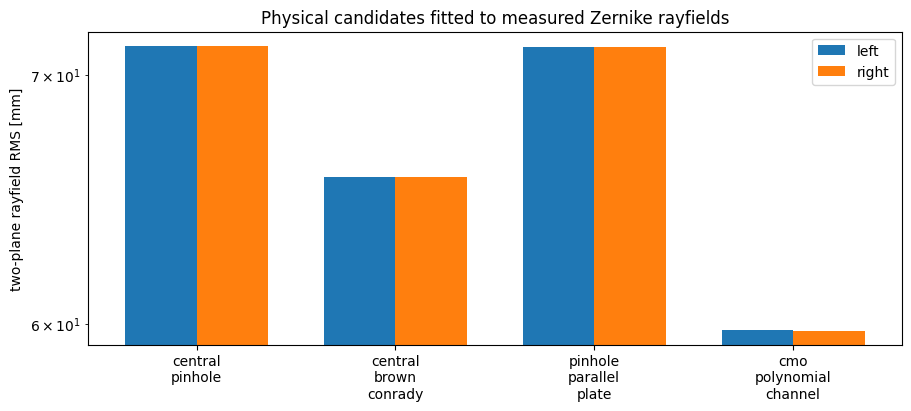

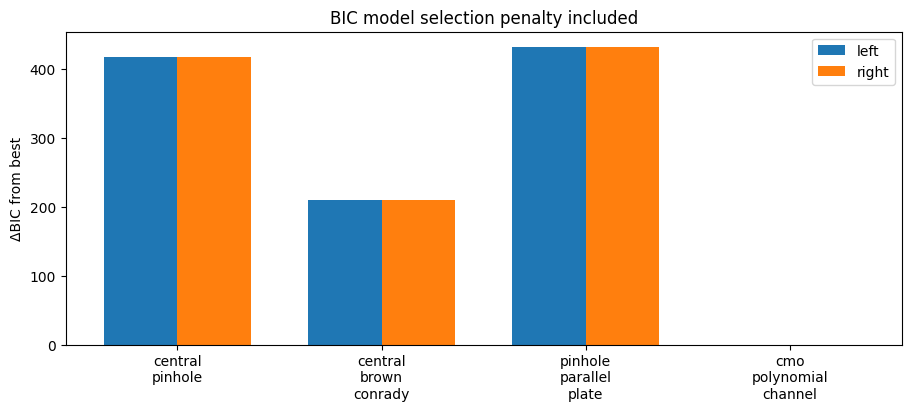

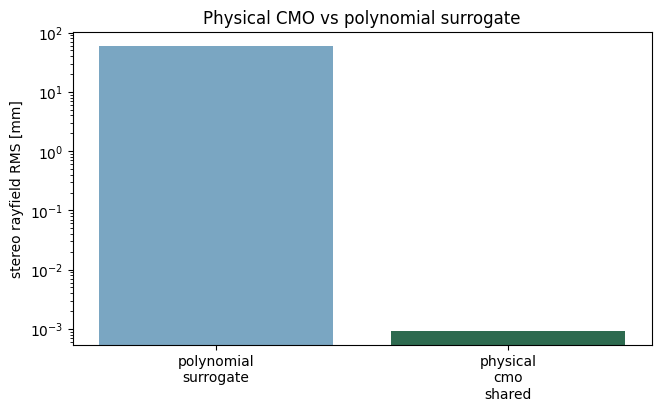

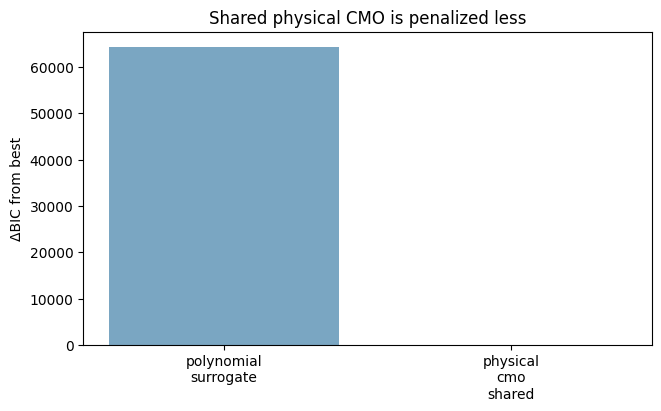

In [7]:
def rows_to_arrays(report):
    rows = report.rows()
    labels = [row["model"].replace("_", "\n") for row in rows]
    rms = np.array([row["rms_mm"] for row in rows], dtype=float)
    bic = np.array([row["bic"] for row in rows], dtype=float)
    return labels, rms, bic


labels, left_rms, left_bic = rows_to_arrays(left_report)
_, right_rms, right_bic = rows_to_arrays(right_report)
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
width = 0.36
ax.bar(x - width / 2, left_rms, width, label="left")
ax.bar(x + width / 2, right_rms, width, label="right")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("two-plane rayfield RMS [mm]")
ax.set_title("Physical candidates fitted to measured Zernike rayfields")
ax.set_yscale("log")
ax.legend()
fig.savefig(ASSET_DIR / "cmo_model_selection_rms.png", dpi=160)
show_or_close(fig)

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
left_delta = left_bic - np.min(left_bic)
right_delta = right_bic - np.min(right_bic)
ax.bar(x - width / 2, left_delta, width, label="left")
ax.bar(x + width / 2, right_delta, width, label="right")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("ΔBIC from best")
ax.set_title("BIC model selection penalty included")
ax.legend()
fig.savefig(ASSET_DIR / "cmo_model_selection_bic.png", dpi=160)
show_or_close(fig)

fig, ax = plt.subplots(figsize=(6.5, 4), constrained_layout=True)
labels_compare = [row["model"].replace("_", "\n") for row in comparison_rows]
rms_compare = [row["rms_mm"] for row in comparison_rows]
colors = ["#7aa6c2", "#2d6a4f"]
ax.bar(labels_compare, rms_compare, color=colors)
ax.set_yscale("log")
ax.set_ylabel("stereo rayfield RMS [mm]")
ax.set_title("Physical CMO vs polynomial surrogate")
fig.savefig(ASSET_DIR / "cmo_physical_vs_polynomial_rms.png", dpi=160)
show_or_close(fig)

fig, ax = plt.subplots(figsize=(6.5, 4), constrained_layout=True)
bic_compare = np.array([row["bic"] for row in comparison_rows], dtype=float)
ax.bar(labels_compare, bic_compare - np.min(bic_compare), color=colors)
ax.set_ylabel("ΔBIC from best")
ax.set_title("Shared physical CMO is penalized less")
fig.savefig(ASSET_DIR / "cmo_physical_vs_polynomial_bic.png", dpi=160)
show_or_close(fig)

## 7. Save a compact JSON report

In [8]:
summary = {
    "left": {
        "best_by_bic": left_report.best_by_bic,
        "rows": left_report.rows(),
        "polynomial_parameters": poly_left.parameter_dict,
    },
    "right": {
        "best_by_bic": right_report.best_by_bic,
        "rows": right_report.rows(),
        "polynomial_parameters": poly_right.parameter_dict,
    },
    "physical_vs_polynomial": comparison_rows,
    "physical_cmo_fit": {
        "success": physical_fit.success,
        "message": physical_fit.message,
        "parameter_dict": physical_fit.parameter_dict,
        "truth_parameter_dict": physical_cmo.parameter_dict(),
        "angular_scale_truth": float(angular_scale_truth),
        "angular_scale_fit": float(angular_scale_fit),
    },
}
(ASSET_DIR / "cmo_model_selection_summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)
print(json.dumps(summary["left"]["rows"], indent=2))

[
  {
    "model": "central_pinhole",
    "parameters": 0,
    "rms_mm": 71.2720655282348,
    "support_rms_mm": 71.2720655282348,
    "full_grid_rms_mm": 70.5531829972908,
    "bic": 8722.644756588108,
    "aic": 8722.644756588108,
    "selected_bic": false
  },
  {
    "model": "central_brown_conrady",
    "parameters": 5,
    "rms_mm": 65.73045614160121,
    "support_rms_mm": 65.73045614160121,
    "full_grid_rms_mm": 65.23666798629151,
    "bic": 8516.150547007677,
    "aic": 8498.705858376894,
    "selected_bic": false
  },
  {
    "model": "pinhole_parallel_plate",
    "parameters": 3,
    "rms_mm": 71.24394183734366,
    "support_rms_mm": 71.24394183734366,
    "full_grid_rms_mm": 70.52433729232683,
    "bic": 8737.959316818407,
    "aic": 8727.492503639938,
    "selected_bic": false
  },
  {
    "model": "polynomial_surrogate_channel",
    "parameters": 17,
    "rms_mm": 59.759409733834524,
    "support_rms_mm": 59.759409733834524,
    "full_grid_rms_mm": 59.395191194050035,
  

## 8. Interpretation

The physical CMO is not selected because the notebook tells the selector that
the oracle is a CMO. The selector only sees the measured Zernike rayfield and
ray-space residuals. Central pinhole and central Brown-Conrady can bend
directions, but they cannot represent the shared non-central sub-pupil
geometry. The inclined-plate model can create non-central rays, but its
geometry is the wrong physical family for this CMO oracle.

The polynomial surrogate is the right engineering fallback for systems whose
structure is unknown or not CMO-like. On this true-CMO oracle, however, the
shared physical CMO should be preferred when it reaches the same ray-space
accuracy with fewer effective degrees of freedom. That is the intended
scientific message:

> Measure the rayfield first; explain the optics second.